PVI
$\left\{\begin{array}{l}\frac{d M}{d r}=4 \pi r^2 \rho(r) \\ \frac{d \rho}{d r}=-\frac{G M(r) \rho(r)}{r^2 \phi}+\alpha \rho(r) \tau \\ M\left(r_0\right)=0, \quad \rho\left(r_0\right)=\rho_0\end{array}\right.$

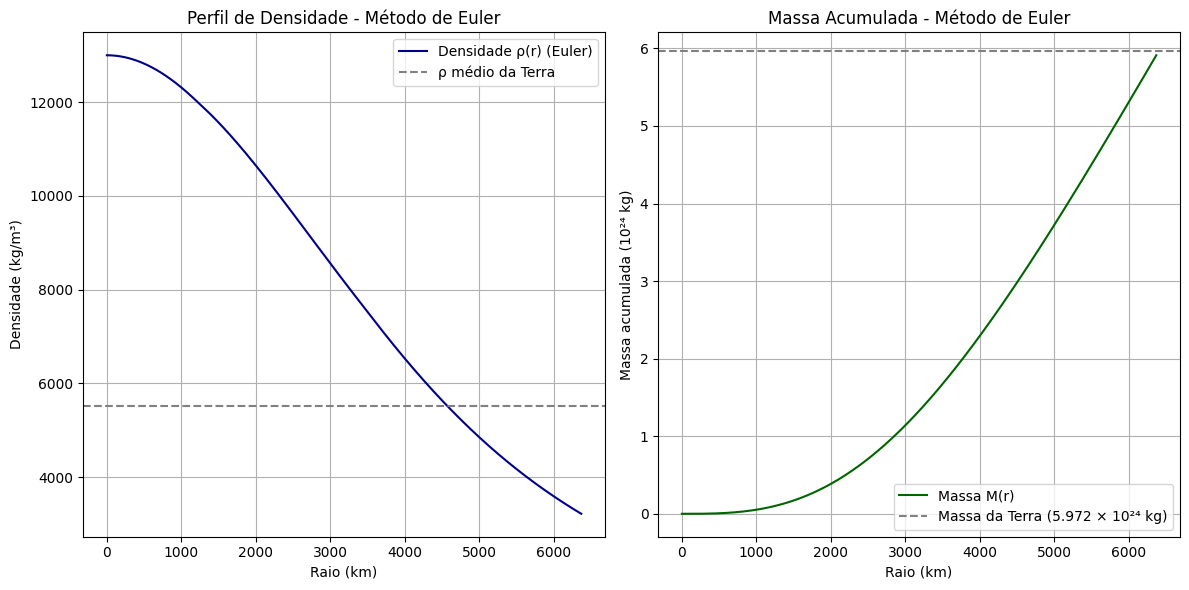

In [16]:
import numpy as np
import matplotlib.pyplot as plt

G = 6.67430e-11
phi = 3.3e7
alpha = 1e-8
tau = 1.0
R_terra = 6371e3
M_terra = 5.972e24
rho_medio = 5514

r0 = 0.1e3
rho0 = 13000
M0 = 0.0

dr = 1e3

r_values = [r0 / 1e3]
rho_values = [rho0]
M_values = [M0]

r = r0
rho = rho0
M = M0

while r <= R_terra and rho > 0:
    dM = 4 * np.pi * r**2 * rho * dr
    M += dM

    drho = (-G * M * rho / (r**2 * phi)) * dr

    if r > 1221e3 and r < 3480e3:
        drho += alpha * rho * tau * dr

    rho += drho
    r += dr

    r_values.append(r / 1e3)
    rho_values.append(rho)
    M_values.append(M)

r_values = np.array(r_values)
rho_values = np.array(rho_values)
M_values = np.array(M_values) / 1e24

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(r_values, rho_values, color='darkblue', label='Densidade ρ(r) (Euler)')
plt.axhline(rho_medio, color='gray', linestyle='--', label='ρ médio da Terra')
plt.xlabel('Raio (km)')
plt.ylabel('Densidade (kg/m³)')
plt.title('Perfil de Densidade - Método de Euler')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(r_values, M_values, color='darkgreen', label='Massa M(r)')
plt.axhline(M_terra / 1e24, color='gray', linestyle='--', label='Massa da Terra (5.972 × 10²⁴ kg)')
plt.xlabel('Raio (km)')
plt.ylabel('Massa acumulada (10²⁴ kg)')
plt.title('Massa Acumulada - Método de Euler')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

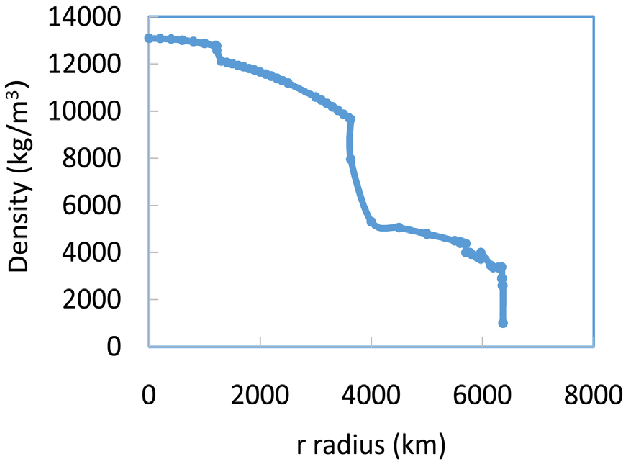

In [17]:
from IPython.display import Image
Image("/content/foto/The-density-of-the-Earth-as-function-of-radius-is-shown-as-determined-from-the-data-in.png")